In this notebook, we explore the dynamics of the "Smart-Predict then Optimize" paper and its proposed surrogate loss function SPO+. Specifically, we explore its performance relative to the tradtiional predict then optimize paradigm with vanilla mean squared error (MSE) prediction loss. Some simple, intentional examples are constructed, to gain some intuition before moving on to more "blackbox" experiments. 

In [1]:
import pyepo
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
import numpy as np
import torch
from torch.utils.data import DataLoader
from torch import nn
import pandas as pd

In [73]:
#-------------------------------------------------------------------------------------------------
#Helper Functions
#-------------------------------------------------------------------------------------------------

#Function to take data points and plot scatter plot with optional regression lines
def plot_2d(x, y, xlbl, ylbl, title=None, regression=None):
    plt.scatter(x,y, c='gray')
    if regression is not None:
        x_line = np.array([min(x), max(x)])
        for line in regression: 
            y_line = line['weights'] * x_line + line['bias']
            plt.plot(x_line, y_line, label=line['type'])
        plt.legend()
    plt.xlabel(xlbl)
    plt.ylabel(ylbl)
    plt.title(title)
    plt.show()

#Function to train models and record statistics
def trainModel(loader_train, loader_test, optmodel, model, criterion, name, epochs=25, lr=1e-1):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    train_loss_log, train_regret_log = [], []
    test_loss_log, test_regret_log = [], []
    
    for epoch in range(epochs):
        # --- TRAINING ---
        model.train()
        temp_loss = []
        for data in loader_train:
            x, c, w, z = data
            cp = model(x)
            
            loss = criterion(cp, c, w, z) if name == "SPO+" else criterion(cp, c)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            temp_loss.append(loss.item())

        # Calculate Training Metrics (Once per epoch)
        train_loss_log.append(np.mean(temp_loss))
        train_regret_log.append(pyepo.metric.regret(model, optmodel, loader_train))

        # --- TESTING ---
        model.eval() # Important for consistency
        temp_loss = []
        with torch.no_grad():
            for data in loader_test:
                x, c, w, z = data
                cp = model(x)
                loss = criterion(cp, c, w, z) if name == "SPO+" else criterion(cp, c)
                temp_loss.append(loss.item())
        
        # Calculate Testing Metrics (Once per epoch)
        test_loss_log.append(np.mean(temp_loss))
        test_regret_log.append(pyepo.metric.regret(model, optmodel, loader_test))

        if epoch % 10 == 0:
            print(f'Epoch: {epoch} Loss Type: {name}')
            print(f'Train Loss {train_loss_log[-1]:.2f} Test Loss {test_loss_log[-1]:.2f}')
            print(f'Train Regret {train_regret_log[-1] *100:.2f}% Test Regret {test_regret_log[-1]*100:.2f}%')

    return train_loss_log, test_loss_log, train_regret_log, test_regret_log

#Funtion to plot trajectory of training curves
def plotLearningCurves(train_loss, test_loss, train_regret, test_regret, name):
    fig, ax = plt.subplots(1, 2, figsize=(16, 6))
    epochs = range(len(train_loss))

    # --- Plot 1: Loss (Prediction Error) ---
    ax[0].plot(epochs, train_loss, label='Train Loss', color='blue', lw=2)
    ax[0].plot(epochs, test_loss, label='Test Loss', color='lightblue', linestyle='--')
    ax[0].set_title(f'{name} Loss Trajectory')
    ax[0].set_xlabel('Epochs')
    ax[0].set_ylabel('Loss Value')
    ax[0].legend()
    ax[0].grid(True, alpha=0.3)

    # --- Plot 2: Regret (Decision Error) ---
    ax[1].plot(epochs, [r * 100 for r in train_regret], label='Train Regret', color='green', lw=2)
    ax[1].plot(epochs, [r * 100 for r in test_regret], label='Test Regret', color='lightgreen', linestyle='--')
    ax[1].set_title(f'{name} Regret Trajectory')
    ax[1].set_xlabel('Epochs')
    ax[1].set_ylabel('Regret (%)')
    ax[1].legend()
    ax[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

#-------------------------------------------------------------------------------------------------
#Models
#-------------------------------------------------------------------------------------------------

#Linear Regression Model
class LinearRegression(nn.Module):
    def __init__(self, num_feat, num_item):
        super(LinearRegression, self).__init__()
        self.linear = nn.Linear(num_feat, num_item)

    def forward(self, x):
        out = self.linear(x)
        return out

#MLP Model
class MLP(nn.Module):
    def __init__(self, num_feat, hidden, num_item):
        super(MLP, self).__init__()
        self.l1 = nn.Linear(num_feat, hidden)
        self.relu = nn.ReLU()
        self.l2 = nn.Linear(hidden, num_item)
        
    def forward(self, x):
        out = self.l1(x)
        out = self.relu(out)
        out = self.l2(out)
        return out

In [ ]:
#Simple Example
#Generate Random Features (num_feat, num_samples)
features = 10 * torch.rand((1,1000))
#Mapping (num_item, num_feat)
item_map = torch.tensor([3, 7, 10], dtype=torch.float32).unsqueeze(1)

#Generate Values from item mapping (num_item, num_samples)
values = item_map @ features
#Add Noise to the values
values += torch.randn_like(values)
#Shift Values so none are at zero
values -= torch.min(values, dim=1, keepdim=True).values

#Add Outliers
values[2] = torch.where(values[2] > 80, 250 + 100 * torch.rand(values[2].shape), values[2])

#Generate Weights (num_item)
weights = torch.tensor([3, 7, 10])

#Set capacity of knapsack
capacity = 10

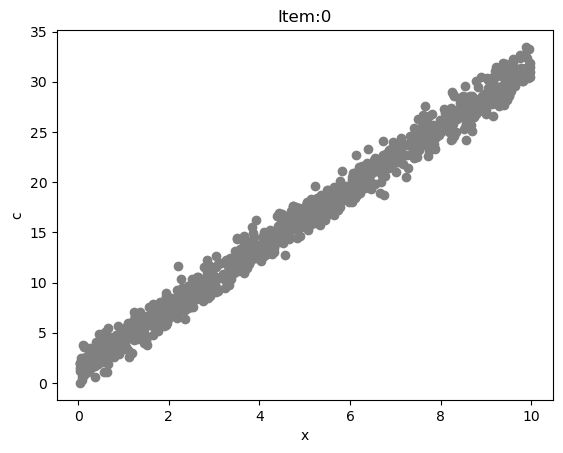

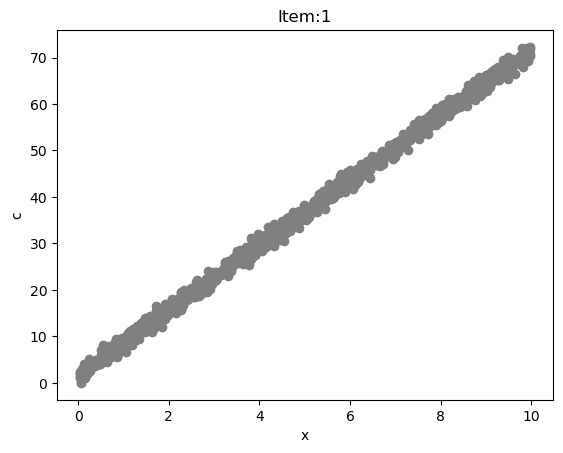

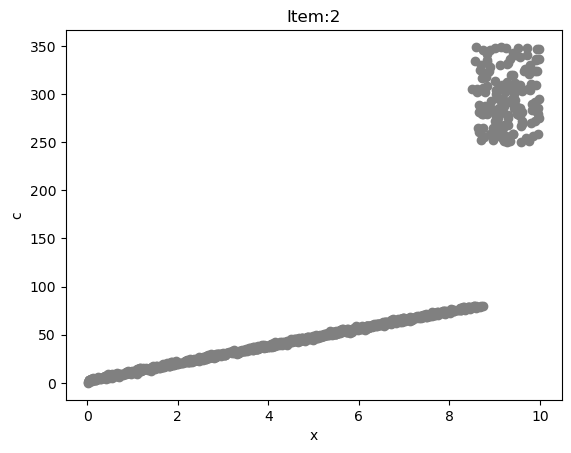

In [84]:
#Visualize the items
for item in range(len(weights)):
    plot_2d(features[0], values[item,], 'x', 'c', f'Item:{item}')

In [85]:
#Partition Data
#Split Data Into Train / Test
feat_train, feat_test, value_train, value_test = train_test_split(features.T, values.T, test_size= int(features.shape[1] *.9))
print(feat_train.shape)
print(value_train.shape)

#Create Optimization Model Datasets, and Data Loaders
optmodel = pyepo.model.grb.knapsackModel(weights.view(1, -1), capacity)
dataset_train = pyepo.data.dataset.optDataset(optmodel, feat_train, value_train)
dataset_test = pyepo.data.dataset.optDataset(optmodel, feat_test, value_test)

batch_size = 32
loader_train = DataLoader(dataset_train, batch_size=batch_size, shuffle=True)
loader_test = DataLoader(dataset_test, batch_size=1, shuffle=False)

torch.Size([100, 1])
torch.Size([100, 3])
Optimizing for optDataset...


100%|██████████| 100/100 [00:00<00:00, 2519.84it/s]

Optimizing for optDataset...



100%|██████████| 900/900 [00:00<00:00, 2745.09it/s]


Epoch: 0 Loss Type: MSE
Train Loss 8170.72 Test Loss 5173.20
Train Regret 39.17% Test Regret 34.75%
Epoch: 10 Loss Type: MSE
Train Loss 3296.54 Test Loss 3459.08
Train Regret 39.17% Test Regret 34.74%
Epoch: 20 Loss Type: MSE
Train Loss 3623.30 Test Loss 2535.40
Train Regret 39.19% Test Regret 34.77%


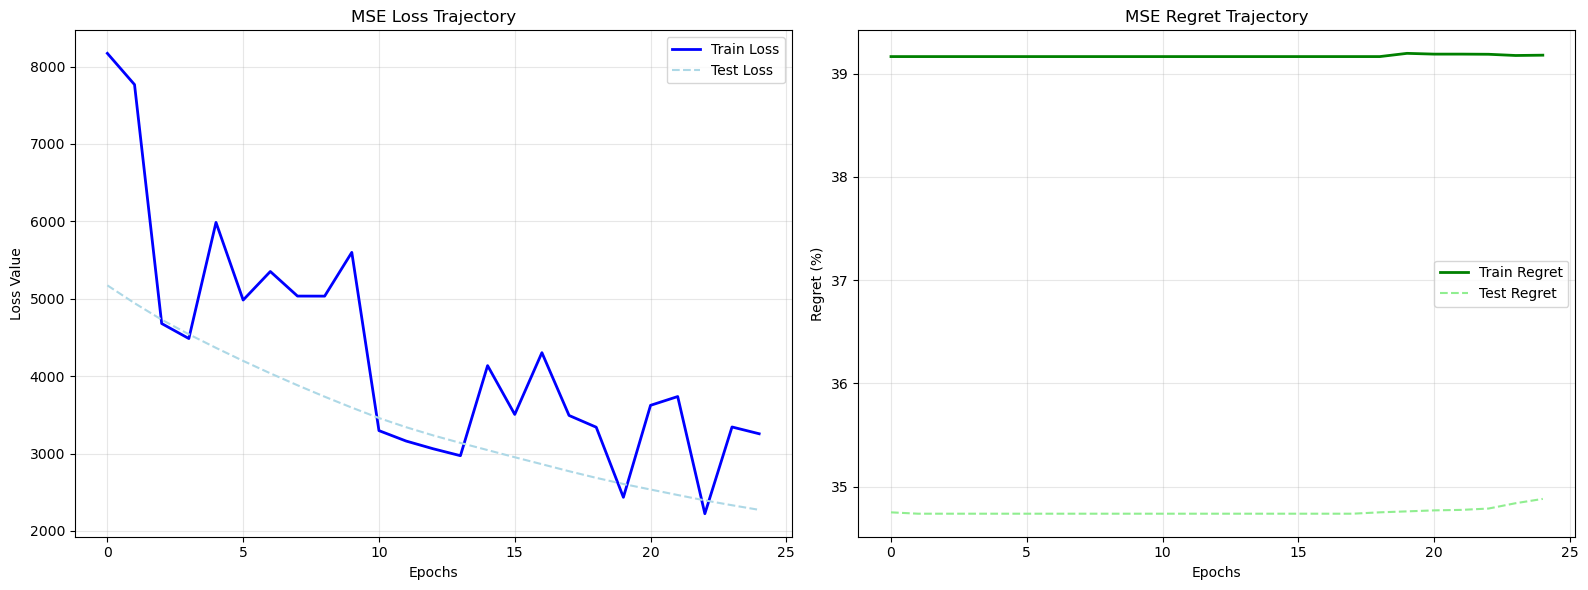

In [86]:
#Train simple Linear Regression with mean squared error
model_mse = LinearRegression(features.shape[0], values.shape[0])
mse = nn.MSELoss()
logs_mse = trainModel(loader_train, loader_test, optmodel, model_mse, mse, "MSE")
plotLearningCurves(*logs_mse, name="MSE")

Num of cores: 1
Epoch: 0 Loss Type: SPO+
Train Loss 86.13 Test Loss 69.61
Train Regret 39.32% Test Regret 35.00%
Epoch: 10 Loss Type: SPO+
Train Loss 44.99 Test Loss 31.25
Train Regret 39.19% Test Regret 34.78%
Epoch: 20 Loss Type: SPO+
Train Loss 28.64 Test Loss 29.48
Train Regret 39.17% Test Regret 34.74%


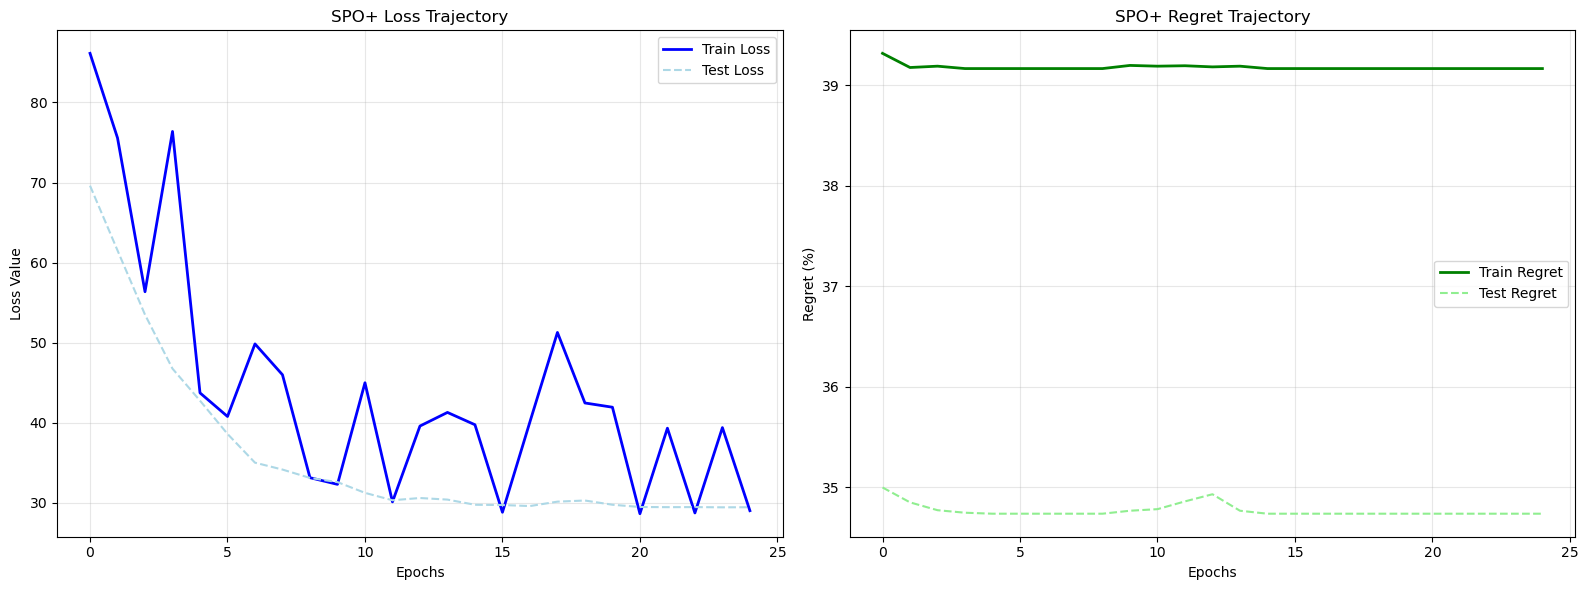

In [87]:
#Train simple Linear Regression with spo+
model_spo = LinearRegression(features.shape[0], values.shape[0])
spo = pyepo.func.SPOPlus(optmodel, processes=1)
logs_spo = trainModel(loader_train, loader_test, optmodel, model_spo, spo, "SPO+")
plotLearningCurves(*logs_spo, name="SPO+")

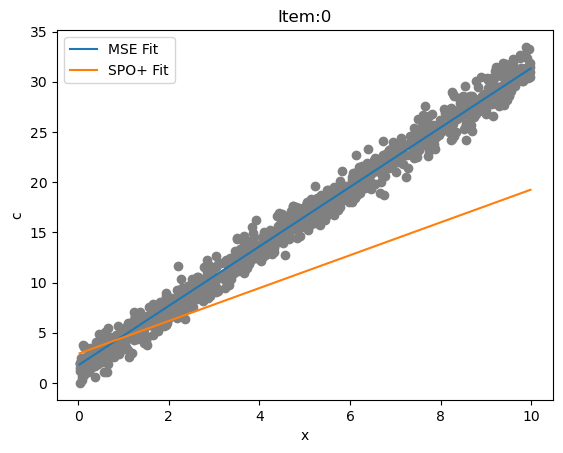

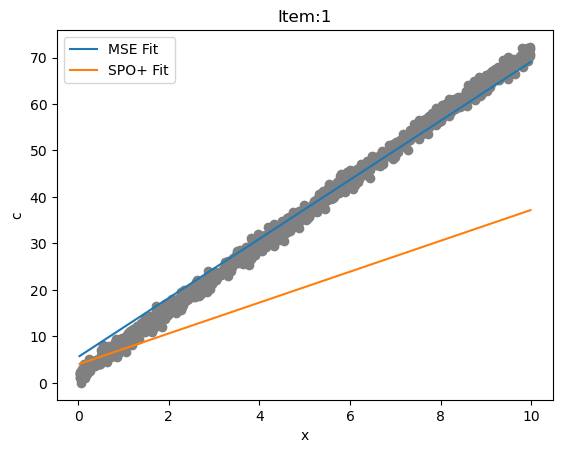

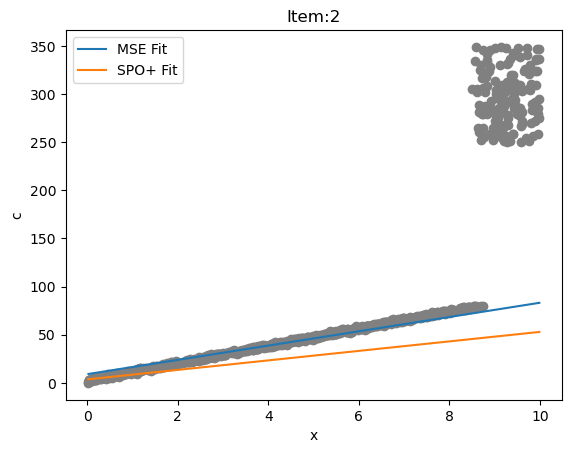

In [88]:
for item in range(len(weights)):
    fits = [
    {'type' : 'MSE Fit', 'weights' : model_mse.linear.weight.detach()[item], 'bias' : model_mse.linear.bias.detach()[item]},
    {'type' : 'SPO+ Fit', 'weights' : model_spo.linear.weight.detach()[item], 'bias' : model_spo.linear.bias.detach()[item]},
    ]
    plot_2d(features[0], values[item,], 'x', 'c', f'Item:{item}', fits)

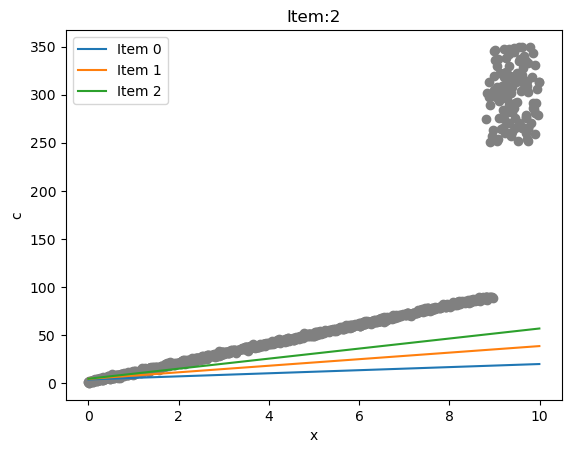

In [63]:
fits = []
for item in range(len(weights)):
    fits.append({'type' : f'Item {item}', 'weights' : model_spo.linear.weight.detach()[item], 'bias' : model_spo.linear.bias.detach()[item]})
    
plot_2d(features[0], values[item,], 'x', 'c', f'Item:{item}', fits)

In [9]:
#Parameters
i = 10 #items
n = 1000 #samples of data
d = 1 #numper of features
p = 1 #power of polynomial cost function
ec = 1 #noise multiplier for generating costs
ew = 5 #noise multiplied for generating weights
capPCT = 0.4 #capacity of knapsack as a % of total weight

#Generate Random Features
x = 10 * torch.rand((d,n))
#Generate Random Mapping
A = torch.randn((i,d))
#Generate Costs
c = (A @ x) ** p 
#Add Noise to Costs
c += ec * (torch.mean(c, dim=1, keepdim=True) * torch.rand(i,1) * torch.randn_like(c))
#Shift Values to have minimum at zero
c -= torch.min(c, dim=1, keepdim=True).values
#Generate Weights
w = torch.mean(c, dim=1) + (ew * torch.std(c, dim=1) * torch.randn(i))
w -= torch.min(w) - 1
#Calculate capacity
capacity = [int(torch.sum(w) * capPCT)]
print(w.shape)

torch.Size([10])


In [6]:
print(f'Avg. Stdev. of Cost to Weight: {torch.mean(torch.std(c / w.unsqueeze(1), dim=0)):.2f}')

Avg. Stdev. of Cost to Weight: 2.14


C:\Users\Loper Laptop\AppData\Local\Temp\ipykernel_31764\154592895.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


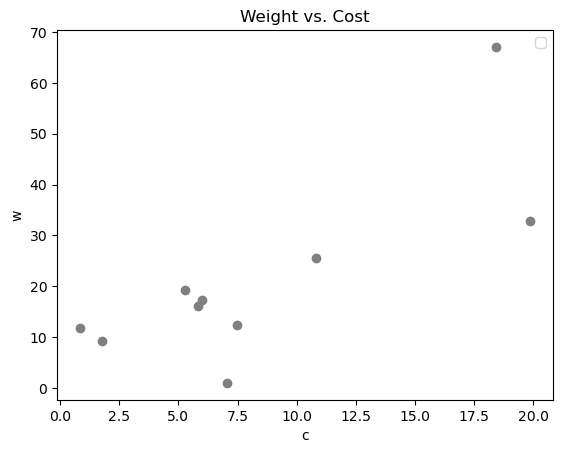

In [ ]:
plot_2d(torch.mean(c, dim=1), w, 'c', 'w', 'Weight vs. Cost')

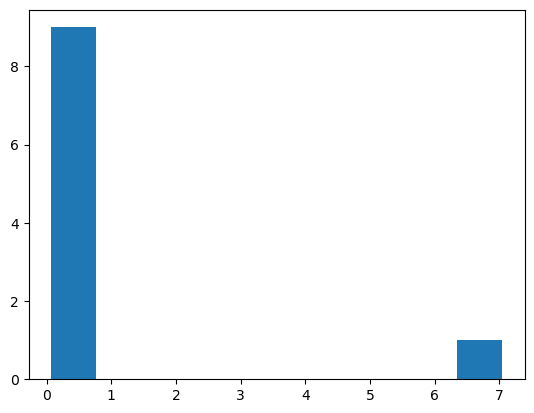

In [9]:
plt.hist(torch.mean(c, dim=1) / w)
plt.show()

In [17]:
labels = [f'Item {i}' for i in range(len(w))]
df = pd.DataFrame({
    "Items" : labels,
    "Weights" : w.tolist(),
    "Avg. Value" : torch.mean(c, dim = 1).tolist(),
    "Avg. Ratio" : (torch.mean(c, dim = 1) / w).tolist()
})
print(df.sort_values(by='Avg. Ratio', ascending=False))

    Items    Weights  Avg. Value  Avg. Ratio
3  Item 3   1.000000    7.043869    7.043869
1  Item 1  32.785988   19.891579    0.606710
0  Item 0  12.423903    7.455101    0.600061
5  Item 5  25.583294   10.821568    0.422994
8  Item 8  16.057194    5.833609    0.363302
9  Item 9  17.335583    6.003517    0.346312
6  Item 6  67.068474   18.437796    0.274910
7  Item 7  19.344952    5.288748    0.273392
4  Item 4   9.202078    1.752771    0.190476
2  Item 2  11.770218    0.816261    0.069350
